In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

device = "MPS" if torch.backends.mps.is_available() else "CPU"
print("Device:", device)
print("✅ Imported!")

Device: MPS
✅ Imported!


In [2]:
# โหลด dataset เดิม
df_train = pd.read_csv('../data/train_cleaned.csv')
df_test = pd.read_csv('../data/test_cleaned.csv')

# โหลด feature engineered dataset เพิ่มค่ะ
df_extra = pd.read_csv('../data/mental_heath_feature_engineered.csv')

print("Original training set:", df_train.shape)
print("Extra dataset:", df_extra.shape)
print("Test set:", df_test.shape)

Original training set: (40012, 7)
Extra dataset: (49612, 21)
Test set: (992, 4)


In [3]:
# เช็คคอลัมน์ใน extra dataset
print("Extra columns:", df_extra.columns.tolist())
print("\nExtra status distribution:")
print(df_extra['status'].value_counts())

Extra columns: ['Unique_ID', 'text', 'status', 'text_length', 'word_count', 'num_urls', 'num_emojis', 'num_special_chars', 'num_excess_punct', 'avg_word_length', 'stopword_ratio', 'type_token_ratio', 'polarity', 'subjectivity', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'has_suicidal_keyword', 'has_stress_keyword', 'has_help_keyword']

Extra status distribution:
status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64


In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    return text

# Clean extra dataset
df_extra['clean_text'] = df_extra['text'].apply(clean_text)

# Standardize column names
df_extra_clean = df_extra[['clean_text', 'status']].copy()
df_train_clean = df_train[['clean_text', 'status']].copy()

# Combine datasets
df_combined = pd.concat([
    df_train_clean,
    df_extra_clean
], ignore_index=True)

# Remove duplicates
df_combined = df_combined.drop_duplicates(
    subset=['clean_text']
).reset_index(drop=True)

print("Combined dataset:", df_combined.shape)
print("\nCombined distribution:")
print(df_combined['status'].value_counts())

Combined dataset: (48841, 2)

Combined distribution:
status
Normal        18073
Depression    14260
Suicidal      11194
Anxiety        5314
Name: count, dtype: int64


In [5]:
# Map to binary
status_map = {
    'Normal'     : 0,
    'normal'     : 0,
    'Anxiety'    : 1,
    'anxiety'    : 1,
    'Depression' : 1,
    'depression' : 1,
    'Suicidal'   : 1,
    'suicidal'   : 1,
    'Stress'     : 1,
    'stress'     : 1,
    'Bipolar'    : 1,
    'bipolar'    : 1
}

df_combined['binary_label'] = df_combined['status'].map(status_map)
df_test['binary_label'] = df_test['status'].map({
    'Normal': 0, 'Anxiety': 1,
    'Depression': 1, 'Suicidal': 1
})

# ลบแถวที่ map ไม่ได้
df_combined = df_combined.dropna(
    subset=['binary_label']
).reset_index(drop=True)

df_combined['binary_label'] = df_combined['binary_label'].astype(int)

print("After mapping:")
print(df_combined['binary_label'].value_counts())

# Balance
min_count = df_combined['binary_label'].value_counts().min()
print("\nSamples per class:", min_count)

df_balanced = pd.concat([
    resample(
        df_combined[df_combined['binary_label'] == label],
        n_samples=min_count,
        replace=False,
        random_state=42
    )
    for label in [0, 1]
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(df_balanced['binary_label'].value_counts())
print("Total:", len(df_balanced))

After mapping:
binary_label
1    30768
0    18073
Name: count, dtype: int64

Samples per class: 18073

After balancing:
binary_label
1    18073
0    18073
Name: count, dtype: int64
Total: 36146


In [6]:
tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)
print("✅ Tokenizer loaded!")

✅ Tokenizer loaded!


In [7]:
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        texts = [str(t) for t in texts]
        labels = [int(l) for l in labels]

        self.encodings = tokenizer(
            texts,
            max_length=max_length,
            padding='max_length',
            truncation=True
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(
                self.encodings['input_ids'][idx],
                dtype=torch.long
            ),
            'attention_mask': torch.tensor(
                self.encodings['attention_mask'][idx],
                dtype=torch.long
            ),
            'labels': torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

train_dataset = MentalHealthDataset(
    texts=df_balanced['clean_text'].values,
    labels=df_balanced['binary_label'].values,
    tokenizer=tokenizer
)

test_dataset = MentalHealthDataset(
    texts=df_test['clean_text'].values,
    labels=df_test['binary_label'].values,
    tokenizer=tokenizer
)

print("✅ Dataset created!")
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

✅ Dataset created!
Training samples: 36146
Test samples: 992


In [8]:
num_labels = 2

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

print("✅ Model loaded!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded!
Parameters: 66,955,010


In [9]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

print("✅ Metrics ready!")

✅ Metrics ready!


In [10]:
training_args = TrainingArguments(
    output_dir='../model/distilbert_v3',
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=3e-5,
    lr_scheduler_type='cosine',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none'
)

print("✅ Arguments set!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Arguments set!


In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3
    )]
)

print("Starting training v3...")
print("Estimated time: 45-60 minutes...")
trainer.train()
print("✅ Training done!")

Starting training v3...
Estimated time: 45-60 minutes...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.163808,0.245102,0.905242,0.907372
2,0.143352,0.145355,0.948589,0.948623
3,0.058694,0.156841,0.954637,0.955538
4,0.048909,0.140782,0.967742,0.968294
5,0.023583,0.140263,0.974798,0.975159
6,0.007287,0.222169,0.968750,0.969337
7,0.005705,0.193144,0.977823,0.978127
8,0.005714,0.245997,0.969758,0.970309
9,0.000068,0.282359,0.964718,0.965456
10,0.000024,0.241718,0.970766,0.971283


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Training done!


In [13]:
# ตรวจสอบ device
device = torch.device(
    'mps' if torch.backends.mps.is_available() else 'cpu'
)
print("Using device:", device)

# ย้าย model ไป device
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

dataloader = DataLoader(test_dataset, batch_size=32)

with torch.no_grad():
    for batch in dataloader:
        # ย้าย data ไป device เดียวกับ model ค่ะ
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # ย้ายกลับมา CPU ก่อน numpy ค่ะ
        preds = torch.argmax(
            outputs.logits, dim=1
        ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

pred_labels = np.array(all_preds)
true_labels = np.array(all_labels)

accuracy = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')

print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ F1 Score: {f1:.4f}")

label_names = ['Normal', 'At-risk']
print("\nClassification Report:")
print(classification_report(
    true_labels, pred_labels,
    target_names=label_names
))

Using device: mps
✅ Accuracy: 0.9778
✅ F1 Score: 0.9781

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96       248
     At-risk       1.00      0.97      0.98       744

    accuracy                           0.98       992
   macro avg       0.96      0.99      0.97       992
weighted avg       0.98      0.98      0.98       992



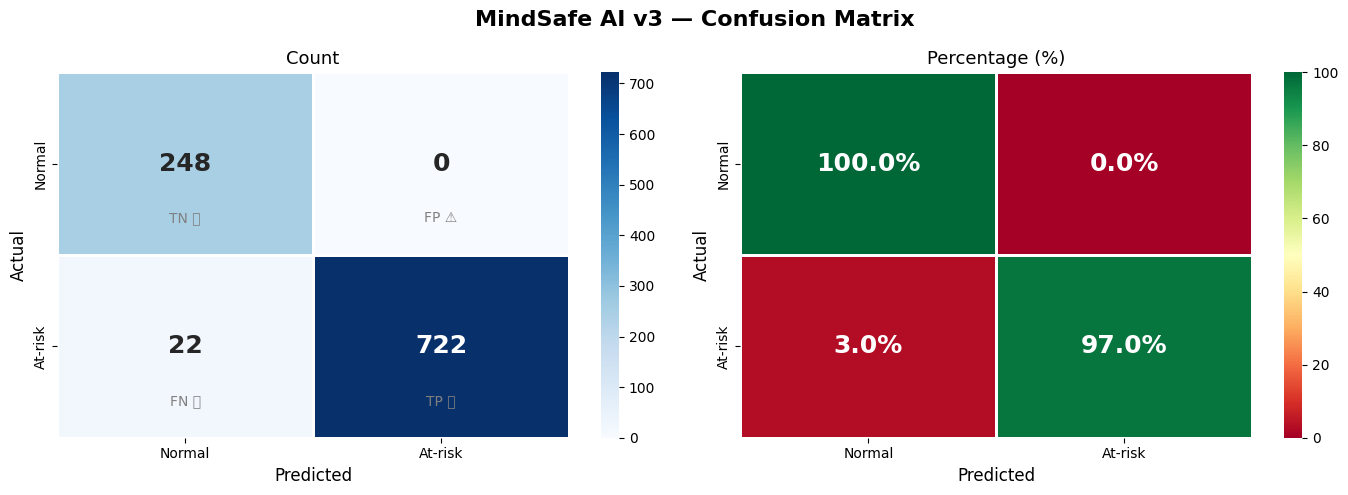


📊 Summary:
TN ✅ = 248 (25.0%)
FP ⚠️  = 0 (0.0%)
FN 🚨 = 22 (2.2%)
TP ✅ = 722 (72.8%)

FN Rate = 3.0%
Recall  = 97.0%
F1      = 0.9781


In [14]:
cm = confusion_matrix(true_labels, pred_labels)
cm_percent = (
    cm.astype('float') /
    cm.sum(axis=1)[:, np.newaxis] * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'MindSafe AI v3 — Confusion Matrix',
    fontsize=16, fontweight='bold'
)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'At-risk'],
    yticklabels=['Normal', 'At-risk'],
    ax=axes[0], linewidths=2,
    annot_kws={'size': 18, 'weight': 'bold'}
)
axes[0].set_title('Count', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

box_labels = [['TN ✅', 'FP ⚠️'], ['FN 🚨', 'TP ✅']]
for i in range(2):
    for j in range(2):
        axes[0].text(
            j+0.5, i+0.82, box_labels[i][j],
            ha='center', fontsize=10, color='gray'
        )

sns.heatmap(
    cm_percent, annot=True, fmt='.1f',
    cmap='RdYlGn',
    xticklabels=['Normal', 'At-risk'],
    yticklabels=['Normal', 'At-risk'],
    ax=axes[1], linewidths=2,
    annot_kws={'size': 18, 'weight': 'bold'},
    vmin=0, vmax=100
)
axes[1].set_title('Percentage (%)', fontsize=13)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

for text in axes[1].texts:
    text.set_text(text.get_text() + '%')

plt.tight_layout()
plt.savefig('../data/confusion_matrix_v3.png',
            dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp
print(f"\n📊 Summary:")
print(f"TN ✅ = {tn:,} ({tn/total*100:.1f}%)")
print(f"FP ⚠️  = {fp:,} ({fp/total*100:.1f}%)")
print(f"FN 🚨 = {fn:,} ({fn/total*100:.1f}%)")
print(f"TP ✅ = {tp:,} ({tp/total*100:.1f}%)")
print(f"\nFN Rate = {fn/(fn+tp)*100:.1f}%")
print(f"Recall  = {tp/(tp+fn)*100:.1f}%")
print(f"F1      = {f1:.4f}")

In [15]:
model.save_pretrained('../model/distilbert_v3')
tokenizer.save_pretrained('../model/distilbert_v3')

import json
label_mapping = {'Normal': 0, 'At-risk': 1}
with open('../model/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

print("✅ Model v3 saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model v3 saved!
